In [1]:
import conntility
import pandas
import numpy
import os

from matplotlib import pyplot as plt

numpy.seterr(all="ignore")


fn = "/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper/Human_NEWfunct_conmat_filtered_compressed.h5"

# We load the data that has been serialized into a single hdf5 file into an object.
M = conntility.ConnectivityMatrix.from_h5(fn)
M = M.index("synapse_class").eq("EXC")

In [2]:
from scipy.spatial import KDTree

xyz = ["x", "y", "z"]
# Build KDTree
tree = KDTree(M.vertices[xyz])

# Query KDTree for nearest neighbor. [2] indicates we ask for the 2nd nearest neighbor. This is, because the neuron itself
# is not excluded from this query and will be the 1st nearest neighbor with a distance of 0
nn_dists, nn_idx = tree.query(M.vertices[xyz], [2])
nn_idx = nn_idx.flatten()

In [3]:
# Set up bins
bin_sz = 50.0
# We create the last bin border at a really large distance to ensure that the last bin captures any remaining pair
bin_borders = numpy.hstack([numpy.arange(0, 1000 + bin_sz, bin_sz), 1E12])
bin_indices = numpy.arange(len(bin_borders) - 1)
# Calculate bin centers. For plotting purporses we consider the really large last bin to be "bin_sz" distance away from the previous.
bin_centers = 0.5 * (bin_borders[:-2] + bin_borders[1:-1])
bin_centers = numpy.hstack([bin_centers, bin_centers[-1] + bin_sz])

In [4]:
# columns "row", and "col" are already part of the data structure we loaded inititally. 
edge_df = M._edge_indices.copy().reset_index(drop=True)

# We can then look up "nn_row", "nn_col" from the array we assembled earlier
edge_df["nn_col"] = nn_idx[M._edge_indices["col"]]
edge_df["nn_row"] = nn_idx[M._edge_indices["row"]]

# M provides a function that yields for each connection the "x", "y" or "z" coordinate of the pre- and post-syn. neurons
# We calculate their distances as "dx", "dy", "dz"
for col_name in xyz:
    per_edge_coords = M.edge_associated_vertex_properties(col_name)
    edge_df["d" + col_name] = per_edge_coords["col"] - per_edge_coords["row"]

# 1-dimensional distance is easily calculated
xyz_delta = ["dx", "dy", "dz"]
edge_df["1d_dist"] = numpy.linalg.norm(edge_df[xyz_delta], axis=1)

# For each connected pair, we calculate which distance bin it belongs to
edge_df["1d_dist_bin"] = numpy.digitize(edge_df["1d_dist"], bins=bin_borders) - 1

# Adjacency matrix. Efficiently represented as a sparse matrix with bool entries
actual_con = M.matrix.tocsc().astype(bool)

# Note that each row of the DataFrame represents one instance where the nearest neighbor of neuron B is connected to A.
# Hence, we can use to easily look up the probability that B is also connected to A.
post_nn_con_mean = actual_con[edge_df["row"], edge_df["nn_col"]].mean()
pre_nn_con_mean = actual_con[edge_df["nn_row"], edge_df["col"]].mean()

print(f"""Overall connection probability: {actual_con.mean()},
      If post-synaptic nearest neighbor is connected: {post_nn_con_mean},
      if pre-synaptic nearest neighbor is connected: {pre_nn_con_mean}""")


Overall connection probability: 0.008930754222055581,
      If post-synaptic nearest neighbor is connected: 0.19122852936456125,
      if pre-synaptic nearest neighbor is connected: 0.16721735446780306


In [5]:
from connalysis.randomization import configuration_model

C = conntility.ConnectivityMatrix(configuration_model(M.matrix),
                                  vertex_properties=M._vertex_properties)

edge_df_ctrl = C._edge_indices.copy().reset_index(drop=True)

# We can then look up "nn_row", "nn_col" from the array we assembled earlier
edge_df_ctrl["nn_col"] = nn_idx[C._edge_indices["col"]]
edge_df_ctrl["nn_row"] = nn_idx[C._edge_indices["row"]]

# M provides a function that yields for each connection the "x", "y" or "z" coordinate of the pre- and post-syn. neurons
# We calculate their distances as "dx", "dy", "dz"
for col_name in xyz:
    per_edge_coords = C.edge_associated_vertex_properties(col_name)
    edge_df_ctrl["d" + col_name] = per_edge_coords["col"] - per_edge_coords["row"]

# 1-dimensional distance is easily calculated
xyz_delta = ["dx", "dy", "dz"]
edge_df_ctrl["1d_dist"] = numpy.linalg.norm(edge_df_ctrl[xyz_delta], axis=1)

edge_df_ctrl["1d_dist_bin"] = numpy.digitize(edge_df_ctrl["1d_dist"], bins=bin_borders) - 1

# Make sure the neuron locations really are identical
assert (M.vertices[xyz] == C.vertices[xyz]).all().all()
# Sparse adjacency matrix
control_con = C.matrix.tocsc().astype(bool)

post_nn_con_mean = control_con[edge_df_ctrl["row"], edge_df_ctrl["nn_col"]].mean()
pre_nn_con_mean = control_con[edge_df_ctrl["nn_row"], edge_df_ctrl["col"]].mean()

print(f"""Overall connection probability: {control_con.mean()},
      If post-synaptic nearest neighbor is connected: {post_nn_con_mean},
      if pre-synaptic nearest neighbor is connected: {pre_nn_con_mean}""")

Overall connection probability: 0.008848980908620296,
      If post-synaptic nearest neighbor is connected: 0.01507657170319475,
      if pre-synaptic nearest neighbor is connected: 0.014816064533913934


In [6]:
# The "count_neighbors" function yields the numbers of pairs at distances up to and including the queried distance. 
# That is, it is a cumulative count. We take the .diff to get the non-cumulative numbers in each bin.
n_pairs_per_bin = numpy.diff(tree.count_neighbors(tree, bin_borders))


In [7]:
prior_con_prob = edge_df.groupby("1d_dist_bin")["1d_dist_bin"].count().reindex(bin_indices) / n_pairs_per_bin

con_prob_post_is_connected = edge_df.groupby("1d_dist_bin").apply(lambda _df: actual_con[_df["row"], _df["nn_col"]].mean(),
                                                                  include_groups=False)
con_prob_pre_is_connected = edge_df.groupby("1d_dist_bin").apply(lambda _df: actual_con[_df["nn_row"], _df["col"]].mean(),
                                                                  include_groups=False)


ctrl_prior_con_prob = edge_df_ctrl.groupby("1d_dist_bin")["1d_dist_bin"].count() / n_pairs_per_bin

ctrl_con_prob_post_is_connected = edge_df_ctrl.groupby("1d_dist_bin").apply(lambda _df: control_con[_df["row"], _df["nn_col"]].mean(),
                                                                  include_groups=False)

ctrl_con_prob_pre_is_connected = edge_df_ctrl.groupby("1d_dist_bin").apply(lambda _df: control_con[_df["nn_row"], _df["col"]].mean(),
                                                                  include_groups=False)

## For post-synaptic NN connected

Text(0, 0.5, 'P')

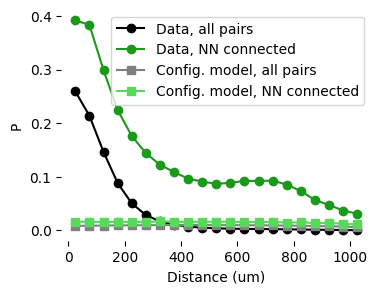

In [8]:
fig = plt.figure(figsize=(4, 3))
ax = fig.gca()

ax.plot(bin_centers[prior_con_prob.index], prior_con_prob, color="black", marker="o", label="Data, all pairs")
ax.plot(bin_centers[con_prob_post_is_connected.index], con_prob_post_is_connected, color=[0.1, 0.6, 0.1],
         label="Data, NN connected", marker="o")

ax.plot(bin_centers[ctrl_prior_con_prob.index], ctrl_prior_con_prob, color="grey", marker="s", label="Config. model, all pairs")
ax.plot(bin_centers[ctrl_con_prob_post_is_connected.index],
         ctrl_con_prob_post_is_connected, color=[0.35, 0.85, 0.35],
         label="Config. model, NN connected", marker="s")

plt.legend()
ax.set_frame_on(False)
ax.set_xlabel("Distance (um)")
ax.set_ylabel("P")


## For pre-synaptic NN connected

Text(0, 0.5, 'P')

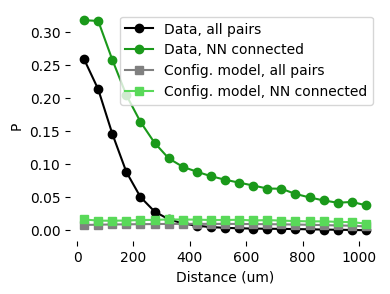

In [9]:
fig = plt.figure(figsize=(4, 3))
ax = fig.gca()

ax.plot(bin_centers[prior_con_prob.index], prior_con_prob, color="black", marker="o", label="Data, all pairs")
ax.plot(bin_centers[con_prob_pre_is_connected.index], con_prob_pre_is_connected, color=[0.1, 0.6, 0.1],
         label="Data, NN connected", marker="o")

ax.plot(bin_centers[ctrl_prior_con_prob.index], ctrl_prior_con_prob, color="grey", marker="s", label="Config. model, all pairs")
ax.plot(bin_centers[ctrl_con_prob_pre_is_connected.index],
         ctrl_con_prob_pre_is_connected, color=[0.35, 0.85, 0.35],
         label="Config. model, NN connected", marker="s")

plt.legend()
ax.set_frame_on(False)
ax.set_xlabel("Distance (um)")
ax.set_ylabel("P")
